# A vs B — Simplified Publication Pipeline

This notebook performs the full workflow:

1. Load `cta.csv`, `headline.csv`, `product.csv`
2. Clean accidental `**` formatting
3. Normalize the exact metric names
4. Merge the three AOIs
5. Validate 8/8 metrics per AOI
6. Apply Benjamini–Hochberg FDR correction
7. Save the merged CSV
8. Generate a clean publication-style figure

### Visual encoding
- same metric = same color across all AOIs
- open colored marker = `p >= .05`
- filled colored marker = raw `p < .05`
- black outer ring = survives BH-FDR (`q < .05`)
- no MAX labels or extra callouts


In [1]:
# Install once if needed:
# %pip install pandas matplotlib statsmodels

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from statsmodels.stats.multitest import multipletests


## 1. Configuration

In [2]:
CSV_FILES = {
    "CTA": "cta.csv",
    "Headline": "headline.csv",
    "Product": "product.csv",
}

MERGED_CSV_OUTPUT = "A_vs_C_merged_results_with_FDR.csv"
OUTPUT_PNG = "A_vs_C_publication_simple.png"
OUTPUT_PDF = "A_vs_C_publication_simple.pdf"

AOI_ORDER = ["CTA", "Headline", "Product"]

CANONICAL_METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

ALPHA = 0.05
PLOT_MAX = 0.38


## 2. Cleaning and exact metric mapping

In [3]:
def clean_column_name(name):
    return str(name).replace("**", "").strip()


def clean_cell(value):
    if pd.isna(value):
        return value
    return str(value).replace("**", "").strip()


EXACT_METRIC_MAP = {
    "VAI%": "VAI (%)",
    "Avg. TTFF": "TTFF (s)",
    "Fix. Avg. Time Spent": "Time spent (s)",
    "Fixations": "Fixations",
    "Avg. Fixation Duration": "Fix. duration (s)",
    "Avg. FFD": "FFD (s)",
    "K-coefficient": "K-coefficient",
    "Avg. Revisits": "Revisits",
}


def canonical_metric(name):
    cleaned = clean_cell(name)

    if cleaned not in EXACT_METRIC_MAP:
        raise ValueError(
            f"Unrecognized metric label: {cleaned!r}\n"
            f"Expected one of: {list(EXACT_METRIC_MAP)}"
        )

    return EXACT_METRIC_MAP[cleaned]


def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace("**", "", regex=False)
              .str.strip(),
        errors="coerce"
    )


def parse_boolean(series):
    return (
        series.astype(str)
              .str.replace("**", "", regex=False)
              .str.strip()
              .str.lower()
              .isin(["true", "1", "yes", "y"])
    )


## 3. Load and prepare CSVs

In [4]:
def load_and_prepare_csv(filename, aoi_name):
    path = Path(filename)

    if not path.exists():
        raise FileNotFoundError(
            f"{filename} was not found. Put it in the same folder as this notebook."
        )

    df = pd.read_csv(path)
    df.columns = [clean_column_name(c) for c in df.columns]

    required = [
        "metric", "n_A", "n_C", "mean_A", "sd_A",
        "mean_C", "sd_C", "F", "df", "p",
        "eta_sq", "levene_p"
    ]

    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(
            f"{aoi_name}: missing columns {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    df.insert(0, "AOI", aoi_name)
    df["metric"] = df["metric"].apply(canonical_metric)
    df["df"] = df["df"].apply(clean_cell)

    numeric_cols = [
        "n_A", "n_C", "mean_A", "sd_A",
        "mean_C", "sd_C", "F", "p",
        "eta_sq", "levene_p"
    ]

    for col in numeric_cols:
        df[col] = clean_numeric(df[col])

    if "significant (p<.05)" in df.columns:
        df["significant_raw"] = parse_boolean(df["significant (p<.05)"])
    elif "significant" in df.columns:
        df["significant_raw"] = parse_boolean(df["significant"])
    else:
        df["significant_raw"] = df["p"] < ALPHA

    return df[
        [
            "AOI", "metric", "eta_sq", "p", "df",
            "n_A", "n_C", "mean_A", "sd_A",
            "mean_C", "sd_C", "F", "levene_p",
            "significant_raw"
        ]
    ].copy()


## 4. Merge and validate

In [5]:
frames = []

for aoi, filename in CSV_FILES.items():
    frames.append(load_and_prepare_csv(filename, aoi))

merged = pd.concat(frames, ignore_index=True)

merged["AOI"] = pd.Categorical(
    merged["AOI"],
    categories=AOI_ORDER,
    ordered=True
)

merged["metric"] = pd.Categorical(
    merged["metric"],
    categories=CANONICAL_METRICS,
    ordered=True
)

merged = merged.sort_values(["AOI", "metric"]).reset_index(drop=True)

errors = []

for aoi in AOI_ORDER:
    sub = merged[merged["AOI"] == aoi]
    present = set(sub["metric"].dropna().astype(str))
    missing = [m for m in CANONICAL_METRICS if m not in present]

    counts = sub["metric"].astype(str).value_counts()
    duplicates = counts[counts > 1].index.tolist()

    print(f"{aoi}: {len(present)}/8 metrics found")

    if missing:
        errors.append(f"{aoi}: missing {missing}")

    if duplicates:
        errors.append(f"{aoi}: duplicates {duplicates}")

if errors:
    raise ValueError(
        "Validation failed; plot generation stopped.\n" + "\n".join(errors)
    )

print("\nValidation passed: 8/8 metrics found for all AOIs.")


CTA: 8/8 metrics found
Headline: 8/8 metrics found
Product: 8/8 metrics found

Validation passed: 8/8 metrics found for all AOIs.


## 5. FDR correction + merged export

In [6]:
reject_fdr, q_values, _, _ = multipletests(
    merged["p"].astype(float).values,
    alpha=ALPHA,
    method="fdr_bh"
)

merged["q_FDR"] = q_values
merged["significant_FDR"] = reject_fdr

def eta_band(x):
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    return "large"

merged["eta_band"] = merged["eta_sq"].apply(eta_band)

merged.to_csv(MERGED_CSV_OUTPUT, index=False)
print(f"Saved merged CSV: {MERGED_CSV_OUTPUT}")


Saved merged CSV: A_vs_C_merged_results_with_FDR.csv


## 6. Simplified final figure

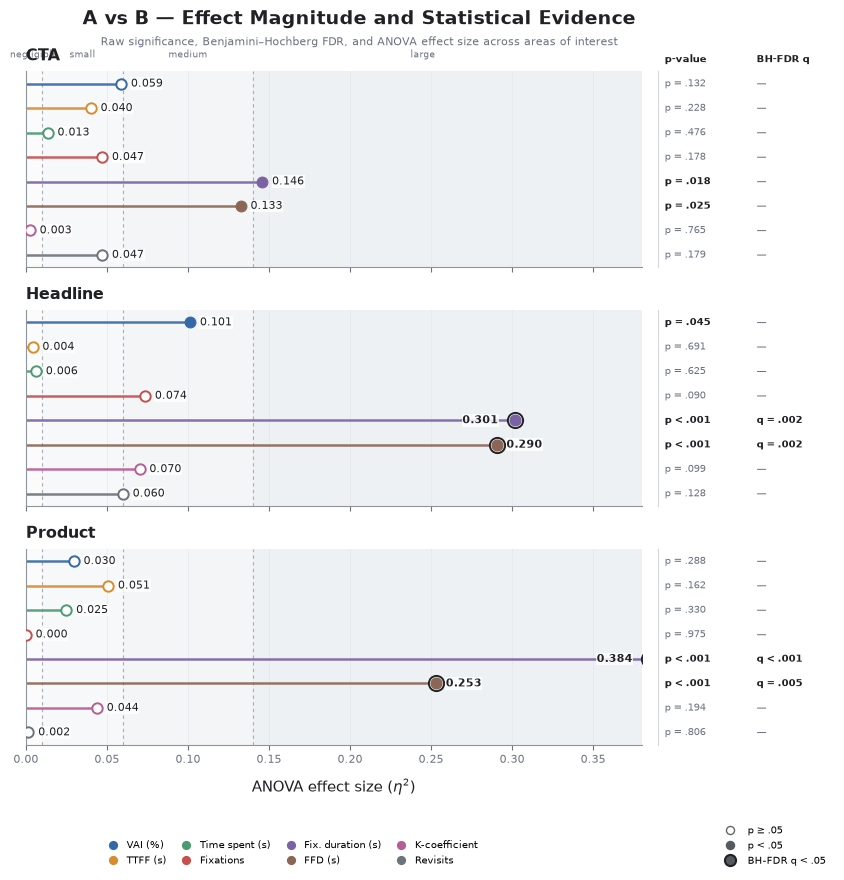

Saved PNG: A_vs_C_publication_simple.png
Saved PDF: A_vs_C_publication_simple.pdf


In [7]:
METRIC_COLORS = {
    "VAI (%)": "#3568A8",
    "TTFF (s)": "#D88C2D",
    "Time spent (s)": "#4B9B72",
    "Fixations": "#C84E4E",
    "Fix. duration (s)": "#7B62A3",
    "FFD (s)": "#8B6656",
    "K-coefficient": "#B85C94",
    "Revisits": "#6C737A",
}

TEXT = "#202124"
MUTED = "#6B7280"
GRID = "#E5E7EB"

def format_p(p):
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}".replace("0.", ".")

def format_q(q):
    if q < 0.001:
        return "q < .001"
    return f"q = {q:.3f}".replace("0.", ".")


fig = plt.figure(figsize=(9.8, 8.8), facecolor="white")

gs = GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[5.4, 1.55],
    wspace=0.04,
    hspace=0.22
)

plot_axes = []
shared_plot_ax = None

for row_idx, aoi in enumerate(AOI_ORDER):

    if shared_plot_ax is None:
        ax = fig.add_subplot(gs[row_idx, 0])
        shared_plot_ax = ax
    else:
        ax = fig.add_subplot(gs[row_idx, 0], sharex=shared_plot_ax)

    stat_ax = fig.add_subplot(gs[row_idx, 1], sharey=ax)

    plot_axes.append(ax)

    sub = merged[merged["AOI"] == aoi].copy().sort_values("metric")
    lookup = {str(row["metric"]): row for _, row in sub.iterrows()}
    y = np.arange(len(CANONICAL_METRICS))

    # subtle effect-size zones
    ax.axvspan(0.00, 0.01, color="#FBFBFC", zorder=0)
    ax.axvspan(0.01, 0.06, color="#F7F8FA", zorder=0)
    ax.axvspan(0.06, 0.14, color="#F3F5F7", zorder=0)
    ax.axvspan(0.14, PLOT_MAX, color="#EEF1F4", zorder=0)

    for yi, metric in enumerate(CANONICAL_METRICS):

        row = lookup[metric]

        eta = float(row["eta_sq"])
        p = float(row["p"])
        q = float(row["q_FDR"])
        raw_sig = bool(row["significant_raw"])
        fdr_sig = bool(row["significant_FDR"])

        color = METRIC_COLORS[metric]

        # keep ALL metric lines in metric color
        ax.hlines(
            yi,
            0,
            eta,
            color=color,
            linewidth=1.8,
            alpha=0.90,
            zorder=2
        )

        # marker style only indicates significance
        if fdr_sig:
            ax.scatter(
                eta, yi,
                s=120,
                facecolor="white",
                edgecolor=TEXT,
                linewidth=1.4,
                zorder=4
            )
            ax.scatter(
                eta, yi,
                s=60,
                facecolor=color,
                edgecolor=color,
                zorder=5
            )

        elif raw_sig:
            ax.scatter(
                eta, yi,
                s=60,
                facecolor=color,
                edgecolor=color,
                linewidth=0.8,
                zorder=4
            )

        else:
            ax.scatter(
                eta, yi,
                s=56,
                facecolor="white",
                edgecolor=color,
                linewidth=1.4,
                zorder=4
            )

        # eta value, simple placement
        if eta >= 0.30:
            x_text = eta - 0.010
            ha = "right"
        else:
            x_text = eta + 0.006
            ha = "left"

        ax.text(
            x_text,
            yi,
            f"{eta:.3f}",
            va="center",
            ha=ha,
            fontsize=8.2,
            fontweight="bold" if fdr_sig else "normal",
            color=TEXT,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.82,
                pad=0.4
            ),
            zorder=6
        )

        # statistics column
        stat_ax.text(
            0.04,
            yi,
            format_p(p),
            va="center",
            ha="left",
            fontsize=7.4,
            fontweight="bold" if raw_sig else "normal",
            color=TEXT if raw_sig else MUTED
        )

        stat_ax.text(
            0.56,
            yi,
            format_q(q) if fdr_sig else "—",
            va="center",
            ha="left",
            fontsize=7.4,
            fontweight="bold" if fdr_sig else "normal",
            color=TEXT if fdr_sig else MUTED
        )

    # left plot
    ax.set_yticks(y)
    ax.set_yticklabels(CANONICAL_METRICS, fontsize=8.5, color=TEXT)
    ax.set_ylim(len(CANONICAL_METRICS) - 0.5, -0.5)
    ax.set_xlim(0, PLOT_MAX)

    ax.set_title(
        aoi,
        loc="left",
        fontsize=11.5,
        fontweight="bold",
        color=TEXT,
        pad=8
    )

    for threshold in [0.01, 0.06, 0.14]:
        ax.axvline(
            threshold,
            linestyle=(0, (3, 3)),
            linewidth=0.8,
            color="#A9AEB5",
            zorder=1
        )

    ax.grid(axis="x", color=GRID, linewidth=0.6, alpha=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#8E949B")
    ax.spines["bottom"].set_color("#8E949B")

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=8, colors=MUTED)

    if row_idx < 2:
        ax.tick_params(axis="x", labelbottom=False)

    # right stats column
    stat_ax.set_xlim(0, 1)
    stat_ax.set_ylim(len(CANONICAL_METRICS) - 0.5, -0.5)
    stat_ax.set_xticks([])
    stat_ax.set_yticks([])

    stat_ax.spines["top"].set_visible(False)
    stat_ax.spines["right"].set_visible(False)
    stat_ax.spines["bottom"].set_visible(False)
    stat_ax.spines["left"].set_color("#D5D8DC")

    if row_idx == 0:
        stat_ax.text(
            0.04, -0.88,
            "p-value",
            fontsize=7.5,
            fontweight="bold",
            color=TEXT
        )

        stat_ax.text(
            0.56, -0.88,
            "BH-FDR q",
            fontsize=7.5,
            fontweight="bold",
            color=TEXT
        )


# effect-size zone labels
top_ax = plot_axes[0]

for x, label in [
    (0.005, "negligible"),
    (0.035, "small"),
    (0.10, "medium"),
    (0.245, "large")
]:
    top_ax.text(
        x,
        1.06,
        label,
        transform=top_ax.get_xaxis_transform(),
        fontsize=6.8,
        ha="center",
        va="bottom",
        color=MUTED,
        clip_on=False
    )


plot_axes[-1].set_xlabel(
    r"ANOVA effect size ($\eta^2$)",
    fontsize=10.5,
    color=TEXT,
    labelpad=9
)

fig.suptitle(
    "A vs B — Effect Magnitude and Statistical Evidence",
    fontsize=13.6,
    fontweight="bold",
    color=TEXT,
    y=0.995
)

fig.text(
    0.5,
    0.965,
    "Raw significance, Benjamini–Hochberg FDR, and ANOVA effect size across areas of interest",
    ha="center",
    va="top",
    fontsize=8.2,
    color=MUTED
)


# metric legend
metric_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=5.6,
        markerfacecolor=METRIC_COLORS[m],
        markeredgecolor=METRIC_COLORS[m],
        label=m
    )
    for m in CANONICAL_METRICS
]

# significance legend
status_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=5.8,
        markerfacecolor="white",
        markeredgecolor="#666666",
        label="p ≥ .05"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=5.8,
        markerfacecolor="#555A60",
        markeredgecolor="#555A60",
        label="p < .05"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=8.0,
        markerfacecolor="#555A60",
        markeredgecolor=TEXT,
        markeredgewidth=1.5,
        label="BH-FDR q < .05"
    ),
]

fig.legend(
    handles=metric_handles,
    loc="lower center",
    bbox_to_anchor=(0.43, 0.012),
    ncol=4,
    frameon=False,
    fontsize=7.2,
    handletextpad=0.35,
    columnspacing=1.0
)

fig.legend(
    handles=status_handles,
    loc="lower right",
    bbox_to_anchor=(0.985, 0.012),
    ncol=1,
    frameon=False,
    fontsize=7.0
)

fig.subplots_adjust(
    left=0.16,
    right=0.985,
    top=0.925,
    bottom=0.16
)

plt.savefig(
    OUTPUT_PNG,
    dpi=450,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved PNG: {OUTPUT_PNG}")
print(f"Saved PDF: {OUTPUT_PDF}")


## 7. Ranked summary table

In [8]:
ranked_results = (
    merged[
        [
            "AOI", "metric", "eta_sq", "eta_band",
            "p", "q_FDR",
            "significant_raw",
            "significant_FDR"
        ]
    ]
    .sort_values(["significant_FDR", "eta_sq"], ascending=[False, False])
    .reset_index(drop=True)
)

ranked_results


,AOI,metric,eta_sq,eta_band,p,q_FDR,significant_raw,significant_FDR
0,Product,Fix. duration (s),0.3844,large,0.0000,0.000000,True,True
1,Headline,Fix. duration (s),0.3015,large,0.0002,0.002400,True,True
2,Headline,FFD (s),0.2905,large,0.0003,0.002400,True,True
3,Product,FFD (s),0.2531,large,0.0009,0.005400,True,True
4,CTA,Fix. duration (s),0.1459,large,0.0180,0.086400,True,False
5,CTA,FFD (s),0.1326,medium,0.0246,0.098400,True,False
6,Headline,VAI (%),0.1014,medium,0.0452,0.154971,True,False
7,Headline,Fixations,0.0736,medium,0.0905,0.262667,False,False
8,Headline,K-coefficient,0.0702,medium,0.0985,0.262667,False,False
9,Headline,Revisits,0.0599,small,0.1281,0.287345,False,False
